In [1]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    MinMaxScaler, 
    OrdinalEncoder,
    OneHotEncoder,
    PowerTransformer,
    QuantileTransformer
)
# Referência
from sklearn.dummy import DummyRegressor

# Linear
from sklearn.linear_model import Lasso, LinearRegression, Ridge

# Árvores
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# SVM
from sklearn.svm import LinearSVR

#kNN
from sklearn.neighbors import KNeighborsRegressor

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_TRATADOS, MODELO_FINAL
from src.graficos import (
    plot_coeficientes,
    plot_comparar_metricas_modelos,
    plot_residuos_estimador
)

from src.models import (
    organiza_resultados,
    treinar_e_validar_modelo_regressao,
    grid_search_cv_regressor,
    RANDOM_STATE
)

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,model_year,transmission,fuel_type,city_l_100_km,highway_l_100_km,combined_l_100_km,co2_emissions_g_km,vehicle_class_grouped,engine_size_l_class,cylinders_class
0,2005,A,reg_gasoline,9.2,7.2,8.3,191,car,up_to_2,up_to_4
1,2005,M,reg_gasoline,9.1,7.3,8.3,191,car,up_to_2,up_to_4
2,2005,A,premium_gasoline,15.9,11.1,13.7,315,suv,up_to_4,up_to_6
3,2005,AS,premium_gasoline,15.1,10.5,13.0,299,car,up_to_4,up_to_6
4,2005,M,premium_gasoline,15.1,10.5,13.0,299,car,up_to_4,up_to_6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21213 entries, 0 to 21212
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   model_year             21213 non-null  int64   
 1   transmission           21213 non-null  object  
 2   fuel_type              21213 non-null  object  
 3   city_l_100_km          21213 non-null  float64 
 4   highway_l_100_km       21213 non-null  float64 
 5   combined_l_100_km      21213 non-null  float64 
 6   co2_emissions_g_km     21213 non-null  int64   
 7   vehicle_class_grouped  21213 non-null  object  
 8   engine_size_l_class    21213 non-null  category
 9   cylinders_class        21213 non-null  category
dtypes: category(2), float64(3), int64(2), object(3)
memory usage: 1.3+ MB


In [4]:
coluna_target = ['co2_emissions_g_km']

colunas_ordinais = ['engine_size_l_class', 'cylinders_class']

colunas_ohe = ['transmission', 'fuel_type', 'vehicle_class_grouped']

colunas_min_max = ['model_year']

colunas_power_transform = ['city_l_100_km', 'highway_l_100_km', 'combined_l_100_km']

In [5]:
preprocessamento = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(categories="auto"), colunas_ordinais),
        ("onehot", OneHotEncoder(drop="first"), colunas_ohe),
        ("min_max", MinMaxScaler(), colunas_min_max),
        ("power_transform", PowerTransformer(), colunas_power_transform),
    ]
)

preprocessamento_arvore = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(categories="auto"), colunas_ordinais),
        ("onehot", OneHotEncoder(drop="first"), colunas_ohe),
    ]
)

In [6]:
X = df.drop(columns=coluna_target)
y = df[coluna_target].values.reshape(-1)

In [7]:
regressors = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer": None,
    },
    # Lineares
    "LinearRegression": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
    "Lasso": {
        "preprocessor": preprocessamento,
        "regressor": Lasso(),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
    "Ridge": {
        "preprocessor": preprocessamento,
        "regressor": Ridge(),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },

    # Baseados em árvore
    "DecisionTreeRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "target_transformer": None,
    },
    "LGBMRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        "target_transformer": None,
    },
    "XGBRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "target_transformer": None,
    },
    # SVM
    "LinearSVR": {
        "preprocessor": preprocessamento,
        "regressor": LinearSVR(max_iter=3000),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
    # kNN
    "KNeighborsRegressor": {
        "preprocessor": preprocessamento,
        "regressor": KNeighborsRegressor(n_jobs=-1),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
}


resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(X, y, **regressor)
    for nome_modelo, regressor in regressors.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

c:\Users\Samuel\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Samuel\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Samuel\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Samuel\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Samuel\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.002996,0.001,-0.000334,-49.97646,-63.292884,0.003996
1,DummyRegressor,0.001,0.001,-0.000009,-50.179021,-63.505441,0.002
2,DummyRegressor,0.002001,0.000999,-0.000189,-49.491658,-63.250965,0.003
3,DummyRegressor,0.002,0.001001,-0.000132,-50.532589,-63.829389,0.003001
4,DummyRegressor,0.001,0.001001,-0.000356,-50.435407,-64.04201,0.002001
5,LinearRegression,0.082243,0.009023,0.9964,-2.470865,-3.796737,0.091266
6,LinearRegression,0.064378,0.008999,0.995752,-2.678095,-4.13917,0.073377
7,LinearRegression,0.073347,0.009996,0.996581,-2.335643,-3.69783,0.083342
8,LinearRegression,0.059228,0.010996,0.996939,-2.393894,-3.531177,0.070225
9,LinearRegression,0.054189,0.009003,0.995948,-2.578955,-4.075645,0.063192


In [8]:
df_resultados.groupby("model").mean().sort_values(by="test_neg_root_mean_squared_error")

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
Lasso,0.060168,0.009023,-0.006522,-49.927281,-63.784573,0.069191
DummyRegressor,0.001799,0.001,-0.000204,-50.123027,-63.584138,0.0028
LGBMRegressor,0.081944,0.011267,0.824032,-20.035197,-26.668648,0.09321
DecisionTreeRegressor,0.044185,0.007009,0.826458,-19.839882,-26.48461,0.051194
XGBRegressor,0.105888,0.012028,0.826495,-19.846013,-26.481785,0.117916
LinearSVR,1.209174,0.00993,0.996044,-2.281056,-3.987447,1.219104
KNeighborsRegressor,0.064241,0.109996,0.996166,-2.037977,-3.934776,0.174237
LinearRegression,0.066677,0.009603,0.996324,-2.49149,-3.848112,0.07628
Ridge,0.068789,0.010401,0.996427,-2.441094,-3.794674,0.07919


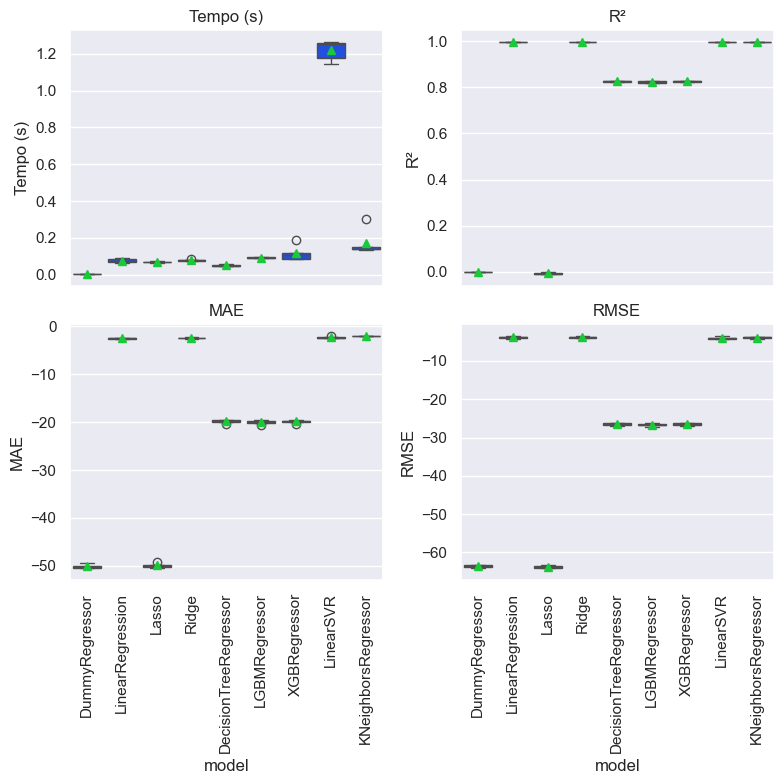

In [9]:
plot_comparar_metricas_modelos(df_resultados)

In [10]:
param_grid = {
    'regressor__reg__alpha': [0.1, 0.5, 1, 2, 5, 10]
}

In [11]:
grid_search = grid_search_cv_regressor(
    regressor=Ridge(),
    preprocessor=preprocessamento,
    target_transformer=QuantileTransformer(output_distribution="normal"),
    param_grid=param_grid,
)

grid_search

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['engine_size_l_class',
                                                                                                               'cylinders_class']),
                                                                                                             ('onehot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['transmission',
                                                                                                               'fuel_type',
                                                                                                               'vehicle_class_grouped']),
                                                                                                             ('min_max',
                                                                                                              Mi...
                                                                                                             ('power_transform',
                                                                                                              PowerTransformer(),
                                                                                                              ['city_l_100_km',
                                                                                                               'highway_l_100_km',
                                                                                                               'combined_l_100_km'])])),
                                                                            ('reg',
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__reg__alpha': [0.1, 0.5, 1, 2, 5, 10]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [12]:
grid_search.fit(X, y)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['engine_size_l_class',
                                                                                                               'cylinders_class']),
                                                                                                             ('onehot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['transmission',
                                                                                                               'fuel_type',
                                                                                                               'vehicle_class_grouped']),
                                                                                                             ('min_max',
                                                                                                              Mi...
                                                                                                             ('power_transform',
                                                                                                              PowerTransformer(),
                                                                                                              ['city_l_100_km',
                                                                                                               'highway_l_100_km',
                                                                                                               'combined_l_100_km'])])),
                                                                            ('reg',
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__reg__alpha': [0.1, 0.5, 1, 2, 5, 10]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [13]:
grid_search.best_params_

{'regressor__reg__alpha': 0.1}

In [14]:
grid_search.best_score_

np.float64(-3.8005766027186807)

In [15]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_.regressor_["reg"].coef_,
    grid_search.best_estimator_.regressor_["preprocessor"].get_feature_names_out(),
)

coefs

,coeficiente
onehot__fuel_type_ethanol,-2.144608
onehot__fuel_type_premium_gasoline,-0.625501
onehot__fuel_type_reg_gasoline,-0.611465
power_transform__combined_l_100_km,-0.148515
onehot__vehicle_class_grouped_special_purpose,-0.038993
onehot__vehicle_class_grouped_suv,-0.022268
onehot__vehicle_class_grouped_pickup_truck,-0.010594
onehot__transmission_M,-0.010522
onehot__vehicle_class_grouped_station_wagon,-0.008561
onehot__transmission_AS,-0.004864


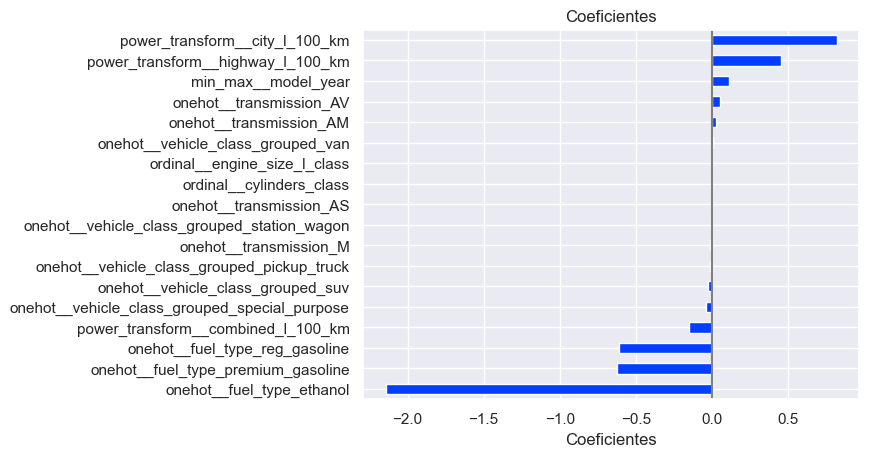

In [16]:
plot_coeficientes(coefs)

As classes são relativas à referência, ou seja, como o modelo pega a primeira categoria ele compara as demais com a primeira, sendo assim, no caso do tipo de combustível
todos emitem menos que a referência (Diesel)


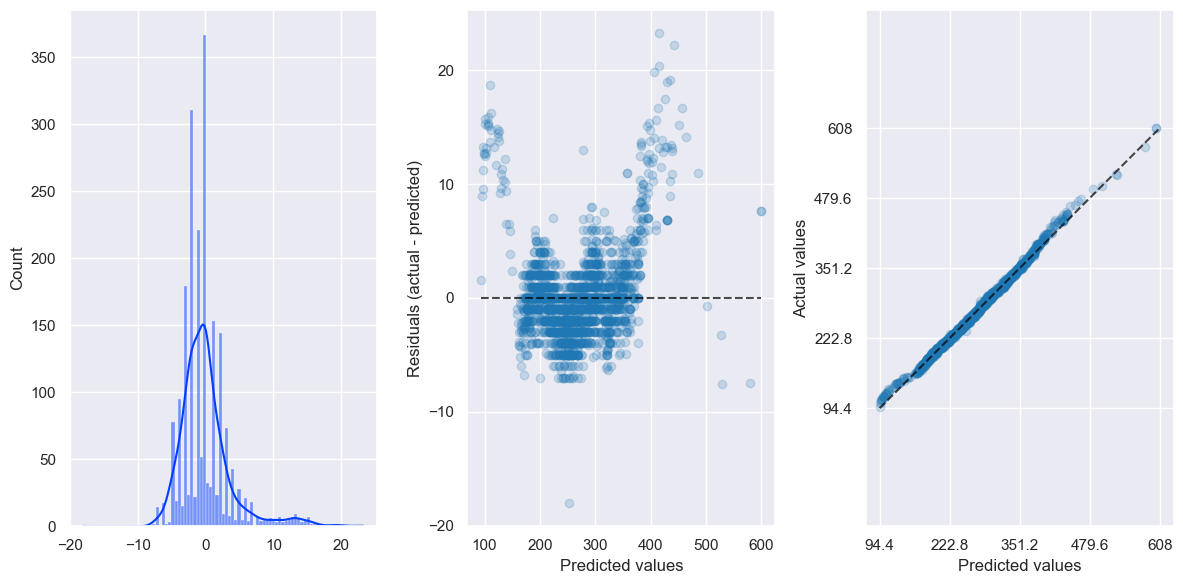

In [17]:
plot_residuos_estimador(grid_search.best_estimator_, X, y, fracao_amostra=0.1, eng_formatter=True)

In [18]:
# Exportando o modelo
from joblib import dump

dump(grid_search.best_estimator_, MODELO_FINAL)

['C:\\Users\\Samuel\\Desktop\\Portfólio Python\\Machine Learning\\09_co2\\modelos\\ridge.joblib']